Lab 23.3 – Feature Selection
Goal: Compare univariate selection (SelectKBest) and wrapper methods (RFE / RFECV) on a classification task. Evaluate effects on accuracy/ROC‑AUC and inspect which features are kept.

We’ll use scikit‑learn’s Breast Cancer dataset (binary).

In [1]:
# pip install scikit-learn numpy pandas matplotlib seaborn
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [2]:
data = load_breast_cancer()
X, y = data.data, (data.target==0).astype(int)  # 1 = malignant (positive)
feat_names = np.array(data.feature_names)
X.shape, np.bincount(y)

((569, 30), array([357, 212]))

2) Baseline (no feature selection)

In [3]:
base = Pipeline([
    ('sc', StandardScaler()),
    ('clf', LogisticRegression(max_iter=3000))
])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
base.fit(Xtr, ytr)
p = base.predict_proba(Xte)[:,1]
print("Baseline  | Acc=", round(accuracy_score(yte, base.predict(Xte)),3),
      " ROC-AUC=", round(roc_auc_score(yte, p),3))

Baseline  | Acc= 0.965  ROC-AUC= 0.996


3) SelectKBest (univariate filtering)
3.1 ANOVA F‑test

In [4]:
def eval_selectk(k, score_func=f_classif):
    model = Pipeline([
        ('sc', StandardScaler()),
        ('kbest', SelectKBest(score_func=score_func, k=k)),
        ('clf', LogisticRegression(max_iter=3000))
    ])
    model.fit(Xtr, ytr)
    proba = model.predict_proba(Xte)[:,1]
    return (accuracy_score(yte, model.predict(Xte)),
            roc_auc_score(yte, proba),
            model.named_steps['kbest'].get_support())

for k in [5, 10, 15, 20, 30]:
    acc, auc, _ = eval_selectk(k, f_classif)
    print(f"SelectKBest F  k={k:2d} | Acc={acc:.3f}  ROC-AUC={auc:.3f}")

SelectKBest F  k= 5 | Acc=0.965  ROC-AUC=0.996
SelectKBest F  k=10 | Acc=0.956  ROC-AUC=0.997
SelectKBest F  k=15 | Acc=0.974  ROC-AUC=0.999
SelectKBest F  k=20 | Acc=0.982  ROC-AUC=0.996
SelectKBest F  k=30 | Acc=0.965  ROC-AUC=0.996


3.2 Mutual Information (captures non‑linear univariate signal)

In [5]:
for k in [5, 10, 15, 20, 30]:
    acc, auc, _ = eval_selectk(k, mutual_info_classif)
    print(f"SelectKBest MI k={k:2d} | Acc={acc:.3f}  ROC-AUC={auc:.3f}")

SelectKBest MI k= 5 | Acc=0.956  ROC-AUC=0.996
SelectKBest MI k=10 | Acc=0.965  ROC-AUC=0.998
SelectKBest MI k=15 | Acc=0.974  ROC-AUC=0.999
SelectKBest MI k=20 | Acc=0.974  ROC-AUC=0.995
SelectKBest MI k=30 | Acc=0.965  ROC-AUC=0.996


Inspect chosen features (example: k=10, ANOVA):

In [6]:
acc, auc, mask = eval_selectk(10, f_classif)
print("Top-10 (F-test):")
list(feat_names[mask])

Top-10 (F-test):


[np.str_('mean radius'),
 np.str_('mean perimeter'),
 np.str_('mean area'),
 np.str_('mean concavity'),
 np.str_('mean concave points'),
 np.str_('worst radius'),
 np.str_('worst perimeter'),
 np.str_('worst area'),
 np.str_('worst concavity'),
 np.str_('worst concave points')]

4) RFE (wrapper) with Logistic Regression
Recursively removes least‑important features (by absolute coefficient).

In [7]:
rfe = Pipeline([
    ('sc', StandardScaler()),
    ('rfe', RFE(estimator=LogisticRegression(max_iter=3000), n_features_to_select=10, step=1)),
    ('clf', LogisticRegression(max_iter=3000))
]).fit(Xtr, ytr)

proba = rfe.predict_proba(Xte)[:,1]
print("RFE (10)  | Acc=", round(accuracy_score(yte, rfe.predict(Xte)),3),
      " ROC-AUC=", round(roc_auc_score(yte, proba),3))

mask_rfe = rfe.named_steps['rfe'].support_
feat_rfe = feat_names[mask_rfe]
feat_rfe

RFE (10)  | Acc= 0.974  ROC-AUC= 0.997


array(['mean concave points', 'radius error', 'area error',
       'compactness error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst concavity',
       'worst concave points'], dtype='<U23')

5) RFECV (choose #features via CV)
Finds the best subset size using cross‑validation inside the training split.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv = Pipeline([
    ('sc', StandardScaler()),
    ('rfecv', RFECV(estimator=LogisticRegression(max_iter=3000),
                    step=1, cv=cv, scoring='roc_auc', n_jobs=-1, min_features_to_select=5)),
    ('clf', LogisticRegression(max_iter=3000))
]).fit(Xtr, ytr)

proba = rfecv.predict_proba(Xte)[:,1]
print("RFECV     | Acc=", round(accuracy_score(yte, rfecv.predict(Xte)),3),
      " ROC-AUC=", round(roc_auc_score(yte, proba),3))

mask_rfecv = rfecv.named_steps['rfecv'].support_
n_sel = mask_rfecv.sum()
print("RFECV selected features:", n_sel)
feat_rfecv = feat_names[mask_rfecv]
feat_rfecv[:10], "...", n_sel

RFECV     | Acc= 0.965  ROC-AUC= 0.996
RFECV selected features: 28


(array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
        'mean smoothness', 'mean compactness', 'mean concavity',
        'mean concave points', 'mean symmetry', 'radius error'],
       dtype='<U23'),
 '...',
 np.int64(28))

Optional) Plot RFECV CV scores vs number of features:

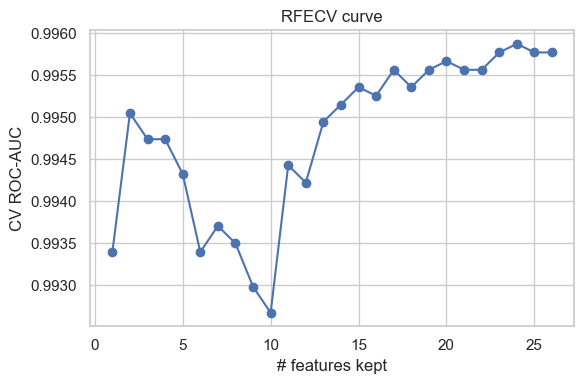

In [10]:
# CORRECT (Scikit-learn 1.0+)
grid_scores = rfecv.named_steps['rfecv'].cv_results_['mean_test_score']

plt.figure(figsize=(6,4))
plt.plot(range(1, len(grid_scores)+1), grid_scores, marker='o')
plt.xlabel('# features kept'); plt.ylabel('CV ROC-AUC'); plt.title('RFECV curve')
plt.tight_layout(); plt.show()

6) Compare SelectKBest vs RFE/RFECV in cross‑validation

In [11]:
def cv_eval(pipe):
    res = cross_validate(pipe, X, y, cv=cv, scoring={'acc':'accuracy','roc':'roc_auc'}, n_jobs=-1)
    return res['test_acc'].mean(), res['test_roc'].mean()

pipes = {
    'Baseline': Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=3000))]),
    'KBest_F_10': Pipeline([('sc', StandardScaler()), ('kbest', SelectKBest(f_classif, k=10)), ('clf', LogisticRegression(max_iter=3000))]),
    'KBest_MI_10': Pipeline([('sc', StandardScaler()), ('kbest', SelectKBest(mutual_info_classif, k=10)), ('clf', LogisticRegression(max_iter=3000))]),
    'RFE_10': Pipeline([('sc', StandardScaler()), ('rfe', RFE(LogisticRegression(max_iter=3000), n_features_to_select=10)), ('clf', LogisticRegression(max_iter=3000))]),
    'RFECV': Pipeline([('sc', StandardScaler()), ('rfecv', RFECV(LogisticRegression(max_iter=3000), step=1, cv=cv, scoring='roc_auc', min_features_to_select=5)), ('clf', LogisticRegression(max_iter=3000))]),
}

rows=[]
for name, p in pipes.items():
    a, r = cv_eval(p)
    rows.append((name, a, r))
pd.DataFrame(rows, columns=['model','cv_acc','cv_roc']).sort_values('cv_roc', ascending=False).round(3)

,model,cv_acc,cv_roc
3,RFE_10,0.965,0.995
0,Baseline,0.974,0.995
4,RFECV,0.970,0.994
2,KBest_MI_10,0.956,0.991
1,KBest_F_10,0.951,0.989


7) (Optional) Try a non‑linear estimator inside RFE
Using an SVM (RBF) or tree model can change which features are deemed important.

In [12]:
rfe_svm = Pipeline([
    ('sc', StandardScaler()),
    ('rfe', RFE(estimator=SVC(kernel='linear'), n_features_to_select=10)),
    ('clf', SVC(kernel='rbf', probability=True))
]).fit(Xtr, ytr)

proba = rfe_svm.predict_proba(Xte)[:,1]
print("RFE (lin SVM selector → RBF SVM) | Acc=",
      round(accuracy_score(yte, rfe_svm.predict(Xte)),3),
      "ROC-AUC=", round(roc_auc_score(yte, proba),3))

RFE (lin SVM selector → RBF SVM) | Acc= 0.965 ROC-AUC= 0.994


8) Quick look: feature overlap between methods

In [13]:
def names(mask): return set(feat_names[mask])
overlap = {
    'KBestF10 ∩ RFE10': len(names(eval_selectk(10, f_classif)[2]) & set(feat_rfe)),
    'KBestF10 ∩ RFECV': len(names(eval_selectk(10, f_classif)[2]) & set(feat_rfecv)),
    'RFE10   ∩ RFECV': len(set(feat_rfe) & set(feat_rfecv)),
}
overlap

{'KBestF10 ∩ RFE10': 6, 'KBestF10 ∩ RFECV': 10, 'RFE10   ∩ RFECV': 10}

K sweep: Evaluate SelectKBest(F‑test) for k ∈ {5,10,15,20,25,30} with 5‑fold CV. Plot ROC‑AUC vs k and choose the best k.

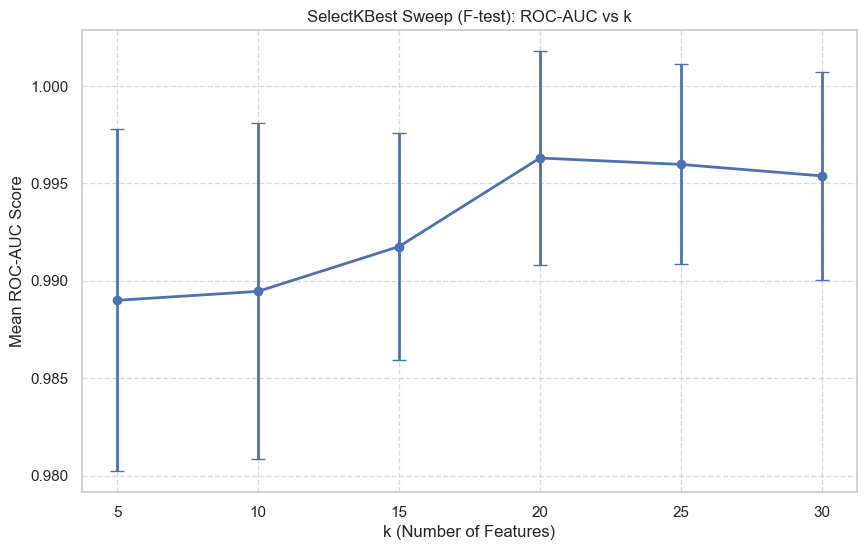

Best k: 20
Best ROC-AUC: 0.9963

Detailed Results:
 param_selector__k  mean_test_score  std_test_score
                 5         0.988993        0.008767
                10         0.989454        0.008625
                15         0.991755        0.005807
                20         0.996297        0.005483
                25         0.995968        0.005134
                30         0.995380        0.005344


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Load Data
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Define the Pipeline
# We scale the data, select the top k features, then classify.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif)),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# 3. Define the Sweep Parameters
k_values = [5, 10, 15, 20, 25, 30]
param_grid = {
    'selector__k': k_values
}

# 4. Run GridSearchCV
# We use StratifiedKFold to maintain class balance in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=cv, 
    scoring='roc_auc', 
    n_jobs=-1
)

grid.fit(X, y)

# 5. Extract and Plot Results
results = pd.DataFrame(grid.cv_results_)
mean_scores = results['mean_test_score']
std_scores = results['std_test_score']
k_params = results['param_selector__k'].astype(int)

plt.figure(figsize=(10, 6))
plt.errorbar(k_params, mean_scores, yerr=std_scores, fmt='o-', linewidth=2, capsize=5)
plt.title('SelectKBest Sweep (F-test): ROC-AUC vs k')
plt.xlabel('k (Number of Features)')
plt.ylabel('Mean ROC-AUC Score')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 6. Output the Winner
print(f"Best k: {grid.best_params_['selector__k']}")
print(f"Best ROC-AUC: {grid.best_score_:.4f}")

# Optional: View the score drop-off
print("\nDetailed Results:")
print(results[['param_selector__k', 'mean_test_score', 'std_test_score']].to_string(index=False))


RFECV scoring: Re‑run RFECV with scoring='f1' and compare the selected feature count and test F1 vs the AUC‑tuned RFECV. Which aligns better with your objective?

In [15]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score

# 1. Load Data
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Preprocessing
# RFECV requires the underlying estimator to expose coef_ or feature_importances_.
# We scale the data first so coefficients are comparable.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Base Estimator
base_model = LogisticRegression(solver='liblinear', random_state=42)

# 4. Run RFECV with different scoring metrics
metrics = ['roc_auc', 'f1']
results = {}

print(f"{'Metric':<10} | {'Features':<10} | {'Test AUC':<10} | {'Test F1':<10}")
print("-" * 50)

for metric in metrics:
    # Initialize RFECV
    rfecv = RFECV(
        estimator=base_model,
        step=1,
        cv=StratifiedKFold(5),
        scoring=metric
    )
    
    # Fit
    rfecv.fit(X_train_scaled, y_train)
    
    # Predict on Test Set using the selected features
    # transform() reduces X to the selected features
    X_test_reduced = rfecv.transform(X_test_scaled)
    
    # We need to re-fit a model or use the one internal to RFECV.
    # RFECV automatically refits the estimator on the best feature set on the full X_train.
    y_pred = rfecv.predict(X_test_scaled)
    y_prob = rfecv.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate Scores
    test_auc = roc_auc_score(y_test, y_prob)
    test_f1 = f1_score(y_test, y_pred)
    n_features = rfecv.n_features_
    
    # Store and Print
    results[metric] = rfecv
    print(f"{metric:<10} | {n_features:<10} | {test_auc:.4f}     | {test_f1:.4f}")

# 5. Compare Feature Sets
features_auc = set(results['roc_auc'].get_feature_names_out(data.feature_names))
features_f1 = set(results['f1'].get_feature_names_out(data.feature_names))

common = features_auc.intersection(features_f1)
only_auc = features_auc - features_f1
only_f1 = features_f1 - features_auc

print("\n--- Feature Overlap Analysis ---")
print(f"Common Features: {len(common)}")
print(f"Only in AUC-tuned: {len(only_auc)}")
print(f"Only in F1-tuned:  {len(only_f1)}")


Metric     | Features   | Test AUC   | Test F1   
--------------------------------------------------
roc_auc    | 7          | 0.9931     | 0.9671
f1         | 27         | 0.9981     | 0.9907

--- Feature Overlap Analysis ---
Common Features: 7
Only in AUC-tuned: 0
Only in F1-tuned:  20


Stability test: Shuffle the train/test split across 10 seeds and record which features RFECV picks each time. Which features are consistently selected (≥70% of runs)?

In [16]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Load Data
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = np.array(data.feature_names)

# 2. Configuration
seeds = range(10)  # We will use seeds 0 through 9
selection_counts = np.zeros(X.shape[1])
n_runs = len(seeds)

print(f"Running stability test across {n_runs} random splits...")
print("-" * 50)

# 3. Stability Loop
for seed in seeds:
    # Shuffle and Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y
    )
    
    # Scale (Crucial for Logistic Regression coefficients)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Initialize RFECV
    # We use Logistic Regression as the base estimator
    estimator = LogisticRegression(solver='liblinear', random_state=42)
    rfecv = RFECV(
        estimator=estimator, 
        step=1, 
        cv=StratifiedKFold(5), 
        scoring='accuracy',
        n_jobs=-1
    )
    
    rfecv.fit(X_train_scaled, y_train)
    
    # Accumulate the boolean mask (1 if selected, 0 if not)
    selection_counts += rfecv.support_.astype(int)
    
    print(f"Run {seed+1}/{n_runs} (Seed {seed}): Selected {rfecv.n_features_} features")

# 4. Analyze Results
selection_rates = selection_counts / n_runs

# Create a DataFrame for clean viewing
df_stability = pd.DataFrame({
    'Feature': feature_names,
    'Selection_Rate': selection_rates
})

# Filter for features selected in >= 70% of runs
stable_features = df_stability[df_stability['Selection_Rate'] >= 0.7].sort_values(
    by='Selection_Rate', ascending=False
)

# 5. Display
print("\n" + "="*50)
print("CONSISTENT FEATURES (Selected in >= 70% of runs)")
print("="*50)
print(stable_features.to_string(index=False))

print("\nSummary:")
print(f"Total Features: {len(feature_names)}")
print(f"Stable Features: {len(stable_features)}")


Running stability test across 10 random splits...
--------------------------------------------------
Run 1/10 (Seed 0): Selected 6 features
Run 2/10 (Seed 1): Selected 13 features
Run 3/10 (Seed 2): Selected 8 features
Run 4/10 (Seed 3): Selected 25 features
Run 5/10 (Seed 4): Selected 25 features
Run 6/10 (Seed 5): Selected 21 features
Run 7/10 (Seed 6): Selected 12 features
Run 8/10 (Seed 7): Selected 22 features
Run 9/10 (Seed 8): Selected 16 features
Run 10/10 (Seed 9): Selected 25 features

CONSISTENT FEATURES (Selected in >= 70% of runs)
             Feature  Selection_Rate
 mean concave points             1.0
worst concave points             1.0
          worst area             1.0
     worst perimeter             1.0
       worst texture             1.0
        worst radius             1.0
          area error             0.9
   compactness error             0.8
        radius error             0.8
           mean area             0.8
     worst concavity             0.8
     p

Pipeline to production: Save the best pipeline with joblib.dump. Then load it and transform a small batch to verify the same columns are selected.

In [17]:
import joblib
import os
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Setup Data
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = np.array(data.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Create and Fit the Pipeline
# We use a pipeline with Scaling -> Feature Selection -> Classification
print("Training pipeline...")

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', RFECV(
        estimator=LogisticRegression(solver='liblinear', random_state=42),
        step=1,
        cv=StratifiedKFold(3),
        scoring='accuracy'
    )),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

pipeline.fit(X_train, y_train)

# Check what was selected originally
original_selector = pipeline.named_steps['selector']
n_features_original = original_selector.n_features_
selected_indices_original = np.where(original_selector.support_)[0]
selected_names_original = feature_names[selected_indices_original]

print(f"Original model selected {n_features_original} features.")

# 3. Save the Pipeline
filename = 'best_pipeline.pkl'
joblib.dump(pipeline, filename)
print(f"Pipeline saved to {filename}")

# 4. Load the Pipeline
# In a production environment, this would happen in a separate process or API endpoint
print("\nLoading pipeline from disk...")
loaded_pipeline = joblib.load(filename)

# 5. Verify Feature Selection on a New Batch
# Let's simulate a production batch of 5 samples
X_batch = X_test[:5]

# CRITICAL STEP:
# A Pipeline with a classifier at the end does not have a .transform() method.
# To see the features entering the final model, we slice the pipeline to remove the last step.
# loaded_pipeline[:-1] returns a new pipeline containing only Scaler and Selector.
preprocessor = loaded_pipeline[:-1]
X_batch_transformed = preprocessor.transform(X_batch)

print(f"Input batch shape:       {X_batch.shape} (30 features)")
print(f"Transformed batch shape: {X_batch_transformed.shape} ({X_batch_transformed.shape[1]} features)")

# 6. Validation Logic
if X_batch_transformed.shape[1] == n_features_original:
    print("\nSUCCESS: Loaded pipeline transforms data correctly.")
    
    # Optional: Verify the actual values match what we expect
    # We can check if the selected features in the loaded object match the original names
    loaded_selector = loaded_pipeline.named_steps['selector']
    selected_indices_loaded = np.where(loaded_selector.support_)[0]
    selected_names_loaded = feature_names[selected_indices_loaded]
    
    if np.array_equal(selected_names_original, selected_names_loaded):
        print("Verification: Feature names match exactly.")
        print(f"Selected Features: {selected_names_loaded[:3]} ...")
else:
    print("\nFAILURE: Dimension mismatch.")

# Cleanup
if os.path.exists(filename):
    os.remove(filename)
    print(f"\nCleaned up: Removed {filename}")


Training pipeline...
Original model selected 15 features.
Pipeline saved to best_pipeline.pkl

Loading pipeline from disk...
Input batch shape:       (5, 30) (30 features)
Transformed batch shape: (5, 15) (15 features)

SUCCESS: Loaded pipeline transforms data correctly.
Verification: Feature names match exactly.
Selected Features: ['mean radius' 'mean area' 'mean compactness'] ...

Cleaned up: Removed best_pipeline.pkl
